In [2]:
# ============================================================================
# SPP constraint-family exposure build — fully inline (no prod-pipeline edits)
# Writes only to temp.* / *_SPP_test tables. Reads prod/dayzer/MySQL read-only.
# ============================================================================
import sys, warnings, re
warnings.filterwarnings("ignore")
sys.path.append("/var/www/python/Qingcheng/nighthawk/")

import pandas as pd, numpy as np
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
from datetime import datetime, timedelta
import pytz
from nighthawk.util import bigquery_functions
from nighthawk.util.sql_functions import download_df_from_sql_db
from nighthawk.data.network.constraint import Constraint
from nighthawk.data.network.constraint_family import ConstraintFamily

OPEX = "SPP"
SUFFIX = "_SPP_test"          # all SPP component tables get this suffix
DATASET = "constraint_family_exposure"
ICE_LABEL = "INDIANAHUB"      # SPP uses INDIANAHUB ice price as proxy (per decision)

bid_dt = (datetime.now(pytz.timezone("America/Chicago")) + timedelta(days=2)).strftime("%Y-%m-%d")
# bid_dt = "2026-06-09"
start_dt = (pd.to_datetime(bid_dt) - pd.Timedelta("2000 day")).strftime("%Y-%m-%d")  # ~3y lookback
end_dt   = bid_dt
mvalue_threshold = 100

print("bid_dt     :", bid_dt)
print("lookback   :", start_dt, "->", end_dt)
print("suffix     :", SUFFIX)


bid_dt     : 2026-06-25
lookback   : 2021-01-02 -> 2026-06-25
suffix     : _SPP_test


# Check for the dayzer flow ratio prediction vs next day actual DART value change. 

In [3]:
# --- Step A: dayzer ConstraintId -> internal oops_constraint_num mapping (SPP) ---
# SPP dayzer names embed the readable monitored line after a colon, e.g.
#   "8765B_LN@HAYMAKR4<13386>:LN HAYMAKR4 - CIMARRON"
# We parse that segment and normalize to match internal monitored_clean.
# Contingency names don't share a convention, so we match MONITORED-ONLY
# (covers ~92% of dayzer SPP CIDs). Approximate — flagged.

dz = bigquery_functions.download_df_from_bq(f"""
    SELECT DISTINCT CID AS ConstraintId, ISOConstraint AS monitored_name, ISOContingency AS contingency_name
    FROM `movetocloud-999.dayzer.ISOName`
    WHERE marketName='{OPEX}' AND CID > 0
""")
internal_da = Constraint(market=OPEX).get_constraint_details(da_or_rt="DA")[
    ["oops_constraint_num", "monitored_clean", "contingency_clean"]].rename(
    columns={"monitored_clean": "monitored_name", "contingency_clean": "contingency_name"})
internal_rt = Constraint(market=OPEX).get_constraint_details(da_or_rt="RT")[
    ["oops_constraint_num", "monitored_clean", "contingency_clean"]].rename(
    columns={"monitored_clean": "monitored_name", "contingency_clean": "contingency_name"})
internal_dart = pd.concat([internal_da, internal_rt])


def _spp_mon_key(s):
    s = str(s)
    if ":" in s:                       
        s = s.split(":", 1)[1]
    return s.lower().replace(" ", "").replace("-", "").replace("_", "")

dz["monitored_key"] = dz["monitored_name"].map(_spp_mon_key)
internal_dart["monitored_key"] = internal_dart["monitored_name"].map(_spp_mon_key)
# internal_rep = internal_dart.drop_duplicates(subset="monitored_key")   # one internal con per monitored key
internal_rep = internal_dart

dayzer_oops_mapping = pd.merge(
    internal_rep[["oops_constraint_num", "monitored_name", "contingency_name", "monitored_key"]],
    dz[["ConstraintId", "monitored_key"]], on="monitored_key", how="inner"
)

dayzer_oops_mapping.drop_duplicates(inplace=True)
dayzer_oops_mapping_bq = bigquery_functions.upload_to_bq_from_dataframe(
    dayzer_oops_mapping, "temp", f"{OPEX}_dayzer_oops_mapping{SUFFIX}", temp=True)

print("dayzer SPP CIDs total      :", dz["ConstraintId"].nunique())
print("mapped CIDs                :", dayzer_oops_mapping["ConstraintId"].nunique(),
      f"({100*dayzer_oops_mapping['ConstraintId'].nunique()/dz['ConstraintId'].nunique():.0f}%)")
print("mapping table              :", dayzer_oops_mapping_bq)
display(dayzer_oops_mapping.head())
print('Not mapped monitored_key at our constraint table are', len(internal_rep[~internal_rep['oops_constraint_num'].isin(dayzer_oops_mapping.oops_constraint_num)].monitored_key.unique())/len(internal_rep.monitored_key.unique()))

print('most of CID 92% already mapped, but 71% of the monitored key not mapped by dayzer, coverage is an issue, will need \
      to see if those monitored key actually happen very small then disregard it if not dayzer is a problem')

dayzer SPP CIDs total      : 2624
mapped CIDs                : 2414 (92%)
mapping table              : temp.SPP_dayzer_oops_mapping_SPP_test


,oops_constraint_num,monitored_name,contingency_name,monitored_key,ConstraintId
0,151242,ln-texas_co,base,lntexasco,1000070
1,683,ln134pentp-mcclai,lnmcclai-saraa138okge,ln134pentpmcclai,3020455
2,4378,ln134pentp-mcclai,lnmcclai-plvala138okge,ln134pentpmcclai,3020455
3,273357,ln134pentp-mcclai,okge:mcclaisara:138:1:7,ln134pentpmcclai,3020455
4,484992,ln134pentp-mcclai,okge:mcclais_lakes:138:1:8,ln134pentpmcclai,3020455


Not mapped monitored_key at our constraint table are 0.7137480628735887
most of CID 92% already mapped, but 71% of the monitored key not mapped by dayzer, coverage is an issue, will need       to see if those monitored key actually happen very small then disregard it if not dayzer is a problem


NT mapping has 932 mapped compared with 1294 mapped by monitored name. 596 important ones mapped compared with 681. 

In [4]:
# select those monitored names that has either da or rt mvalue smaller than -1000 
# 3-year window ending at bid_dt
start_3y = (pd.Timestamp(bid_dt) - pd.Timedelta(days=2000)).strftime("%Y-%m-%d")

# per-constraint summed mvalue over 3y (granularity=None -> overall sum per constraint)
mv_da = Constraint(oops_constraint_num_df=None, market=OPEX).get_mvalues(
    start_dt=start_3y, end_dt=bid_dt, type="DA", granularity=None)
mv_rt = Constraint(oops_constraint_num_df=None, market=OPEX).get_mvalues(
    start_dt=start_3y, end_dt=bid_dt, type="RT", granularity=None)

# map oops_constraint_num -> monitored_name, then sum per monitored
omap = internal_dart[["oops_constraint_num", "monitored_name"]].drop_duplicates("oops_constraint_num")
da_sum = (mv_da.merge(omap, on="oops_constraint_num", how="left")
          .groupby("monitored_name")["mvalue"].sum().rename("DA_mvalue"))
rt_sum = (mv_rt.merge(omap, on="oops_constraint_num", how="left")
          .groupby("monitored_name")["mvalue"].sum().rename("RT_mvalue"))

dart = pd.concat([da_sum, rt_sum], axis=1).fillna(0).reset_index()

# keep monitored with DA or RT 3y-sum below -1000
dart_select = dart[(dart["DA_mvalue"] < -1000) | (dart["RT_mvalue"] < -1000)].reset_index(drop=True)
dart_select = dart_select.sort_values(["DA_mvalue", "RT_mvalue"]).reset_index(drop=True)
print("monitored kept:", len(dart_select.monitored_name.unique()))


monitored kept: 1710


In [5]:
dart_select.nunique()

monitored_name    1710
DA_mvalue         1500
RT_mvalue         1006
dtype: int64

# 1. Create Dayzer Mapping and dayzer related variables 


In [6]:
# whole-market mapping (ConstraintId <-> oops_constraint_num_da), contingency-aware
mapping_da = Constraint(oops_constraint_num_df=None, market=OPEX).get_dayzer_constraint_mapping_da()
mapping_rt = Constraint(oops_constraint_num_df=None, market=OPEX).get_dayzer_constraint_mapping_rt()
mapping = pd.concat([mapping_da, mapping_rt])
mapped_monitored = internal_dart[internal_dart['oops_constraint_num'].isin(mapping.oops_constraint_num_da)].monitored_name.unique()
print('mapped_monitored_name total are', len(mapped_monitored))
print('mapped in the dart -1000 are',dart_select[dart_select["monitored_name"].isin(mapped_monitored)].monitored_name.nunique())
unmapped_ones = set(mapped_monitored).difference(set(dart_select.monitored_name))
dart_unmapped = dart_select[~dart_select["monitored_name"].isin(mapped_monitored)].reset_index(drop=True)
dart_mapped = dart_select[dart_select["monitored_name"].isin(mapped_monitored)].reset_index(drop=True)

print('unmapped_monitored in dart smaller than -1000 are ', len(dart_unmapped))
print('mapped by joining by monitored name not constraint name and contingency name', len(dart_select[dart_select['monitored_name'].isin(dayzer_oops_mapping.monitored_name)].monitored_name.unique()))


mapped_monitored_name total are 939
mapped in the dart -1000 are 743
unmapped_monitored in dart smaller than -1000 are  967
mapped by joining by monitored name not constraint name and contingency name 868


In [7]:
print('mapped total RT select over the total RT select, ', dart_mapped.RT_mvalue.sum()/dart_select.RT_mvalue.sum())
print('mapped total DA select over the total RT select, ', dart_mapped.DA_mvalue.sum()/dart_select.DA_mvalue.sum())

mapped total RT select over the total RT select,  0.9099002613471757
mapped total DA select over the total RT select,  0.8572287624719288


In [8]:
print('if not using the NT, the additional mapping would be', set(dart_select[dart_select['monitored_name'].isin(dayzer_oops_mapping.monitored_name)].monitored_name.unique()).difference(set(dart_select[dart_select["monitored_name"].isin(mapped_monitored)].monitored_name.unique())))

if not using the NT, the additional mapping would be {'lnadrian5-butl_mps', 'lnriffin-anders_9', 'lnhickman-southtwn', 'lngavins-spiritm', 'xfmrjericho_-jericho_', 'lnn_loup-ord1', 'lnbismark2-campblco', 'lnsummitw-bobs_co', 'lnogalala-brule', 'lnsiouxcy2-siouxcy2', 'lnunridge-morr', 'lnstan_tp-beulh7th', 'lnedgeley-edgeley', 'lndeafsmit-tblanca', 'lnlostdraw-cochran', 'lnmoore_co-potter_s', 'xfmrcarlisle-carlisle', 'lnmoore_co-rbfaria', 'lnanita-anta_tp', 'lnpaola-cntrvill', 'lnlelando-antelop', 'lnclasn-crosstwn', 'lnsub_a-subk', 'lneastruth-dunning', 'lnsmit-bail_wr', 'lnjamestn-edgeley', 'lnozrk_b-omaha', 'lnblair-watertn', 'lnbent-rose', 'lnnundrwd-elswrth', 'lngranitf-willmru', 'lnfarb-ksc10', 'lnmandan-wardwa', 'lndovers1-doversub', 'lnsharper5-archie', 'lntulsa_no-denver_t', 'lnpaxton-elsietp', 'lnquincy_s-sp-frnk3', 'lnhebron4-mandan', 'lnjamestn-pickrtwa', 'lnsub1398-sub975', 'lnft_cal-ft_cal', 'lntblanca-hereford', 'lnivanhoew-white', 'lndrftsnd4-santafe4', 'lnfrankln-hamp_t

In [9]:
# oops_constraint_num -> constraint_family_num  (same method all markets use)
oops_family = Constraint(
    pd.DataFrame({"oops_constraint_num": mapping["oops_constraint_num_da"].unique()}),
    market=OPEX
).get_constraint_family_num()
# cols: oops_constraint_num, constraint_family_num

# attach family onto the dayzer mapping (CID -> oops -> family)
dayzer_family = mapping.merge(
    oops_family.rename(columns={"oops_constraint_num": "oops_constraint_num_da"}),
    on="oops_constraint_num_da", how="left").rename(columns={"oops_constraint_num_da": "oops_constraint_num"})
print('total unique ones', mapping.ConstraintId.nunique())
print("CIDs:", dayzer_family["ConstraintId"].nunique(),
      "| with family:", dayzer_family["constraint_family_num"].notna().sum(), "/", len(dayzer_family))
dayzer_family.head()

mapped_monitored = internal_dart[internal_dart['oops_constraint_num'].isin(dayzer_family.oops_constraint_num)].monitored_name.unique()
print('mapped_monitored_names are', len(mapped_monitored))
print('num of constraint family',dayzer_family.constraint_family_num.nunique())
print('num of monitored', dayzer_family.monitored_name.nunique())

total unique ones 1622
CIDs: 1622 | with family: 3374 / 3374
mapped_monitored_names are 939
num of constraint family 939
num of monitored 939


In [10]:
# russett - sbrown oops_constriaint_num is  mapped
internal_da = Constraint(market=OPEX).get_constraint_details(da_or_rt="DA")[
    ["oops_constraint_num", "monitored_clean", "contingency_clean"]].rename(
    columns={"monitored_clean": "monitored_name", "contingency_clean": "contingency_name"})
rsbrown= internal_da[internal_da['monitored_name']=='lnrussett-sbrown']
print(dayzer_family[dayzer_family['oops_constraint_num'].isin(rsbrown.oops_constraint_num)])
dayzer_family_bq = bigquery_functions.upload_to_bq_from_dataframe(
    dayzer_family,
    "temp",
    f"{OPEX}_dayzer_family{SUFFIX}",
    temp=True,
)
print("uploaded:", dayzer_family_bq)

      oops_constraint_num                       constraint_name       monitored_name                    contingency_name  ConstraintId  constraint_family_num
150                297731  SBROWN_7454_A_LN:LN RUSSETT - SBROWN  LN RUSSETT - SBROWN                                BASE       5002392                 167423
403                814690      TMP158_32185:LN RUSSETT - SBROWN  LN RUSSETT - SBROWN      CSWS:VALLIANT PITTSB9:345:1:10       3021674                 167423
1030               503828      TMP159_24149:LN RUSSETT - SBROWN  LN RUSSETT - SBROWN   OKGE:CANEY1 BODLE BROWN2:138:7:33       5001614                 167423
1319               537062      TMP159_24149:LN RUSSETT - SBROWN  LN RUSSETT - SBROWN   OKGE:BROWN2 BODLE CANEY1:138:7:33       5003688                 167423
1334               537084      TMP563_26603:LN RUSSETT - SBROWN  LN RUSSETT - SBROWN  OKGE WFEC:SUNNYSDE HUGOPP4:345:1:1       5001686                 167423
1575               603431      TMP361_28741:LN RUSSE

In [11]:
# --- Step C: dayzer FlowRatio per constraint_family per day (SPP) ---
# Mirrors the MISO/PJM daily block: aggregate to worst-hour FlowRatio per constraint,
# then pick the top-FlowRatio constraint (rank=1) per (dt, family).
# flow_query = f"""
# SELECT CAST(dt AS STRING) AS dt, oops_constraint_num, constraint_family_num, ShadowPrice, Flows, FlowRatio, MinFlowLimit, MaxFlowLimit
# FROM (
#   SELECT dt, ConstraintId, oops_constraint_num, constraint_family_num,
#          SUM(ShadowPrice) AS ShadowPrice, MAX(Flows) AS Flows,
#          MAX(MinFlowLimit) AS MinFlowLimit, MIN(MaxFlowLimit) AS MaxFlowLimit,
#          MAX(CASE WHEN Flows < 0 THEN Flows/NULLIF(MinFlowLimit,0) ELSE Flows/NULLIF(MaxFlowLimit,0) END) AS FlowRatio,
#          ROW_NUMBER() OVER (PARTITION BY dt, constraint_family_num ORDER BY
#              MAX(CASE WHEN Flows < 0 THEN Flows/NULLIF(MinFlowLimit,0) ELSE Flows/NULLIF(MaxFlowLimit,0) END) DESC) AS rnk
#   FROM (
#     SELECT CAST(Date AS DATE) AS dt, CAST(Hour AS INT) AS hr, a.ConstraintId,
#            b.oops_constraint_num, c.constraint_family_num,
#            ShadowPrice, Flows, MinFlowLimit, MaxFlowLimit
#     FROM `movetocloud-999.dayzer.resultConstraintVE` AS a
#     INNER JOIN `movetocloud-999.{dayzer_oops_mapping_bq}` AS b ON a.ConstraintId = b.ConstraintId
#     INNER JOIN `movetocloud-999.{oops_family_bq}`         AS c ON b.oops_constraint_num = c.oops_constraint_num
#     WHERE DATE(Date) BETWEEN DATE('{start_dt}') AND DATE('{end_dt}')
#       AND marketName = '{OPEX}' AND ScenarioId = 1
#   )
#   GROUP BY dt, ConstraintId, oops_constraint_num, constraint_family_num
# )
# ORDER BY constraint_family_num, dt
# """
# dayzer_table_bq = bigquery_functions.create_temp_table_from_query(
#     flow_query, "temp", f"{OPEX}_dayzer_table{SUFFIX}", temp=True)
# print("dayzer_table:", dayzer_table_bq)

# q = f"SELECT COUNT(*) n, COUNT(DISTINCT constraint_family_num) fams, MIN(dt) mn, MAX(dt) mx FROM `movetocloud-999.{dayzer_table_bq}`"
# print(bigquery_functions.download_df_from_bq(q).to_dict("records"))


flow_query = f"""
SELECT CAST(dt AS STRING) AS dt, constraint_family_num, monitored_name, oops_constraint_num,ConstraintId,
       ShadowPrice, Flows, FlowRatio, MinFlowLimit, MaxFlowLimit
FROM (
  SELECT dt, constraint_family_num, monitored_name,oops_constraint_num, ConstraintId,
         SUM(ShadowPrice) AS ShadowPrice, MAX(Flows) AS Flows,
         MAX(MinFlowLimit) AS MinFlowLimit, MIN(MaxFlowLimit) AS MaxFlowLimit,
         MAX(CASE WHEN Flows < 0 THEN Flows/NULLIF(MinFlowLimit,0)
                  ELSE Flows/NULLIF(MaxFlowLimit,0) END) AS FlowRatio
  FROM (
    SELECT CAST(Date AS DATE) AS dt, CAST(Hour AS INT) AS hr, a.ConstraintId,
           b.constraint_family_num, b.monitored_name, b.oops_constraint_num,
           ShadowPrice, Flows, MinFlowLimit, MaxFlowLimit
    FROM `movetocloud-999.dayzer.resultConstraintVE` AS a
    INNER JOIN `movetocloud-999.{dayzer_family_bq}` AS b ON a.ConstraintId = b.ConstraintId
    WHERE DATE(Date) BETWEEN DATE('{start_dt}') AND DATE('{end_dt}')
      AND marketName = '{OPEX}' AND ScenarioId = 1
  )
  GROUP BY dt, constraint_family_num, monitored_name, oops_constraint_num, ConstraintId
)
ORDER BY dt
"""
dayzer_table_bq = bigquery_functions.create_temp_table_from_query(
    flow_query, "temp", f"{OPEX}_dayzer_table{SUFFIX}", temp=True)


In [12]:
# === Dayzer coverage of historically-binding constraint families (5y) ===
from nighthawk.data.network.constraint_family import ConstraintFamily

# 1) constraint-family DA/RT mvalue, daily, past 5 years  (one row per dt x family)
end_5y   = end_dt
start_5y = (pd.Timestamp(end_dt) - pd.Timedelta(days=365*5)).strftime("%Y-%m-%d")

cf  = ConstraintFamily(OPEX, constraint_family_num_df=None)
da5 = cf.get_mvalues(start_5y, end_5y, type="DA", granularity="daily").rename(columns={"mvalue": "dam"})
rt5 = cf.get_mvalues(start_5y, end_5y, type="RT", granularity="daily").rename(columns={"mvalue": "rtm"})
mv5 = da5.merge(rt5, on=["constraintFamilyNum", "dt"], how="outer")
mv5[["dam", "rtm"]] = mv5[["dam", "rtm"]].fillna(0)
mv5 = mv5.rename(columns={"constraintFamilyNum": "constraint_family_num"})
mv5["dt"] = pd.to_datetime(mv5["dt"]).dt.strftime("%Y-%m-%d")

# 2) dayzer FlowRatio per (dt, family) -- collapse the multi-constraint rows to the worst
dz = bigquery_functions.download_df_from_bq(
    f"SELECT dt, constraint_family_num, MAX(FlowRatio) AS FlowRatio "
    f"FROM `movetocloud-999.{dayzer_table_bq}` GROUP BY dt, constraint_family_num")
dz["dt"] = dz["dt"].astype(str)

# 3) LEFT merge mvalue (left) with dayzer FlowRatio on (dt, family)
ds = mv5.merge(dz, on=["dt", "constraint_family_num"], how="left")

In [13]:

# ---- metrics ----
# 1. monitored = family-days binding in DA or RT (mvalue <= -200)
monitored = ds[(ds["dam"] <= -1000) | (ds["rtm"] <= -1000)]
total = len(monitored)
print("1) total monitored constraint-family-days (DA or RT mvalue <= -200):", total)

# 2. mapped = of those, how many have a non-null dayzer FlowRatio
mapped = int(monitored["FlowRatio"].notna().sum())
print(f"2) mapped (non-null FlowRatio) / total: {mapped}/{total} = {mapped/total:.4f}" if total else "no monitored rows")

mapped_dz = monitored[monitored['FlowRatio'].notna()]

# mvalue over the sum of mvalue 
print('mvalue mapped over the sum of mvalue rt:', mapped_dz.rtm.sum()/monitored.rtm.sum() )
print('mvalue mapped over the sum of mvalue da:', mapped_dz.dam.sum()/monitored.dam.sum() )

mapped = mapped_dz[mapped_dz['FlowRatio'].notna()]

# dt-level count coverage: mapped rows / total rows, then averaged across days
count_cov = mapped.groupby('dt').size() / monitored.groupby('dt').size()
print('dt level mapped % (avg):', round(count_cov.mean(), 4))

# dt-level mvalue coverage: mapped mvalue / total mvalue, then averaged across days
mv_cov = mapped.groupby('dt')['dam'].sum() / monitored.groupby('dt')['dam'].sum()
print('mvalue dt level (avg):', round(mv_cov.mean(), 4))

# unique family_num has been mapped 
print('mapped unique constraint family num are', mapped_dz.constraint_family_num.nunique()/monitored.constraint_family_num.nunique())
print('num of family num', monitored.constraint_family_num.nunique())

1) total monitored constraint-family-days (DA or RT mvalue <= -200): 22403
2) mapped (non-null FlowRatio) / total: 18810/22403 = 0.8396
mvalue mapped over the sum of mvalue rt: 0.8902355395346243
mvalue mapped over the sum of mvalue da: 0.8531487154469517
dt level mapped % (avg): 0.8589
mvalue dt level (avg): 0.8749
mapped unique constraint family num are 0.46618933969769294
num of family num 1257


In [14]:
table = bigquery_functions.download_df_from_bq(
    f"SELECT * FROM `movetocloud-999.{dayzer_table_bq}` ORDER BY FlowRatio DESC")

In [15]:
# # how many distinct oops each ConstraintId maps to/ some constraintID mapps to 2 oops_constraint_num but constraint_fam num is sstill the same 

# cnt = table.groupby("ConstraintId")["oops_constraint_num"].nunique().sort_values(ascending=False)
# multi = cnt[cnt > 1]
# print(f"{len(multi)} / {table['ConstraintId'].nunique()} ConstraintIds map to >1 oops_constraint_num")
# print("counts:\n", cnt.value_counts())          # e.g. mostly 2 -> the ~doubling


# # the offending rows, so you can see WHY they split
# offenders = (table[table["ConstraintId"].isin(multi.index)]
#              [["ConstraintId", "oops_constraint_num", "monitored_name"]]
#              .drop_duplicates()
#              .sort_values(["ConstraintId", "oops_constraint_num"]))
# offenders

# Many repetition for single constraint num per day, meaning that dayzer would give multiple predictions per day, so might need to pick the lowest mvalue for that day. Each consraintID would mapped to 1/2/3 oops_constraint by the monitored name. lnwr_smkhl-summ would have 17 constraintID each map to 17 oops constraint num by the monitored name. So each day has prediction of ~17 constraintID, Dayzer gives each ConstraintID 24 prediction each hour has one, we would query for each day the max flowratio of the day's prediction. We would calculate per groupby dt, constraint_fam_num, oops_constraint_num, ConstraintID, max flow for that oops constraint num to append the historical oops_constraint_num mvalue to it, then we would further give the per constraint_fam level, what is max flow ratio for that day and the mvalue sum for the day to backtest. 

In [16]:
from nighthawk.data.network.constraint import Constraint

con_df = table[['oops_constraint_num']].drop_duplicates()
d0, d1 = table['dt'].min(), table['dt'].max()

# oops_constraint_num -> monitored name
mon = pd.concat([
    Constraint(market='SPP').get_constraint_details('DA'),
    Constraint(market='SPP').get_constraint_details('RT'),
])[['oops_constraint_num', 'monitored_clean']].rename(
    columns={'monitored_clean': 'monitored_name'}
).dropna(subset=['monitored_name']).drop_duplicates('oops_constraint_num')

# DA & RT mvalue for those constraints, across the table's date range
da = Constraint(oops_constraint_num_df=con_df, market='SPP').get_mvalues(
        start_dt=d0, end_dt=d1, type='DA', granularity='daily').rename(columns={'mvalue': 'da_mvalue'})
rt = Constraint(oops_constraint_num_df=con_df, market='SPP').get_mvalues(
        start_dt=d0, end_dt=d1, type='RT', granularity='daily').rename(columns={'mvalue': 'rt_mvalue'})

dart = da[['oops_constraint_num', 'dt', 'da_mvalue']].merge(
       rt[['oops_constraint_num', 'dt', 'rt_mvalue']],
       on=['oops_constraint_num', 'dt'], how='outer')
dart['dt'] = pd.to_datetime(dart['dt']).dt.strftime('%Y-%m-%d')

# append onto the dayzer table
table_merged = (table
         .merge(mon,  on=['oops_constraint_num'], how='left')
         .merge(dart, on=['oops_constraint_num', 'dt'], how='left')).rename(columns = {'monitored_name_y':'monitored_name', 'monitored_name_x':'monitored'})

cols = ['dt', 'constraint_family_num', 'oops_constraint_num', 'monitored_name',
        'FlowRatio', 'Flows', 'ShadowPrice', 'da_mvalue', 'rt_mvalue']

# select the max FlowRatio for each monitored line, for example lnwr_smkhl-summ has 17 constraintID,
agg = (table_merged
       .groupby(['dt', 'monitored_name', 'constraint_family_num'], as_index=False)
       .agg(da_mvalue=('da_mvalue', 'sum'),
            rt_mvalue=('rt_mvalue', 'sum'),
            FlowRatio=('FlowRatio', 'max'),
            ShadowPrice_min=('ShadowPrice', 'min'),
            ShadowPrice_sum=('ShadowPrice', 'sum'),
            MinFlowLimit=('MinFlowLimit', 'min'),
            MaxFlowLimit=('MaxFlowLimit', 'max'),
            n_constraints=('oops_constraint_num', 'nunique')))


display(table_merged[cols].sort_values(['dt', 'FlowRatio'], ascending=[True, False]))
display(agg.sort_values(['dt', 'FlowRatio'], ascending=[True, False]))

,dt,constraint_family_num,oops_constraint_num,monitored_name,FlowRatio,Flows,ShadowPrice,da_mvalue,rt_mvalue
26957,2021-01-02,572.0,281258.0,lnnses-ram452,1.000043,150.006424,-312.664406,-330.9751,NaN
26959,2021-01-02,572.0,456970.0,lnnses-ram452,1.000043,150.006424,-312.664406,NaN,NaN
26960,2021-01-02,572.0,447102.0,lnnses-ram452,1.000043,150.006424,-312.664406,NaN,NaN
26962,2021-01-02,572.0,287383.0,lnnses-ram452,1.000043,150.006424,-312.664406,NaN,-519.5786
27006,2021-01-02,535.0,378817.0,lnnash_mps-lbrtywt5,1.000043,140.005966,-157.912722,NaN,NaN
...,...,...,...,...,...,...,...,...,...
5679997,2026-06-24,299.0,753170.0,lngracmont-anadarko,0.000000,0.000000,0.000000,NaN,NaN
5681797,2026-06-24,1040.0,266.0,xfmrquaycnty-quaycnty,0.000000,0.000000,0.000000,NaN,NaN
5683669,2026-06-24,608253.0,292581.0,xfmrexirawa-exirawa,0.000000,0.000000,0.000000,NaN,NaN
5683670,2026-06-24,116151.0,578065.0,lnpittsb9-valliant,0.000000,0.000000,0.000000,NaN,NaN


,dt,monitored_name,constraint_family_num,da_mvalue,rt_mvalue,FlowRatio,ShadowPrice_min,ShadowPrice_sum,MinFlowLimit,MaxFlowLimit,n_constraints
313,2021-01-02,lnnses-ram452,572.0,-330.9751,-519.5786,1.000043,-312.664406,-1250.657624,-201.0,201.0,22
293,2021-01-02,lnnash_mps-lbrtywt5,535.0,-381.5184,0.0000,1.000043,-157.912722,-631.650887,-140.0,140.0,4
218,2021-01-02,lnlaramie-laramie,1074103.0,0.0000,0.0000,1.000001,0.000000,0.000000,-570.0,570.0,2
569,2021-01-02,xfmrlaramie-laramie,997.0,0.0000,0.0000,1.000001,0.000000,0.000000,-570.0,570.0,2
85,2021-01-02,lncolby3-gem_sw3,507719.0,0.0000,0.0000,0.999988,-2445.748961,-2445.748961,-89.0,89.0,1
...,...,...,...,...,...,...,...,...,...,...,...
1616778,2026-06-24,xfmrnevada-nevada,1025.0,0.0000,0.0000,0.000000,0.000000,0.000000,-99999.0,99999.0,1
1616788,2026-06-24,xfmrpalo_dur-palo_dur,1032.0,0.0000,0.0000,0.000000,0.000000,0.000000,-99999.0,99999.0,1
1616793,2026-06-24,xfmrpioneerg-pioneerg,1033.0,0.0000,0.0000,0.000000,0.000000,0.000000,-64.0,64.0,1
1616800,2026-06-24,xfmrquaycnty-quaycnty,1040.0,0.0000,0.0000,0.000000,0.000000,0.000000,-9999.0,9999.0,1


In [17]:
table_merged

,dt,constraint_family_num,monitored,oops_constraint_num,ConstraintId,ShadowPrice,Flows,FlowRatio,MinFlowLimit,MaxFlowLimit,monitored_name,da_mvalue,rt_mvalue
0,2025-06-22,1109604.0,LN BISMARK2 - CPC_EBIS,521984.0,3023014.0,-4800.000000,141.067627,2.015252,-70.0,70.0,lnbismark2-cpc_ebis,NaN,NaN
1,2024-08-06,803.0,LN TEXAS_CO - LIBERAL_,339077.0,3021891.0,3340.881614,76.739182,1.953293,-80.0,80.0,lntexas_co-liberal_,NaN,NaN
2,2024-08-06,439.0,LN LIBERAL_ - TEXAS_CO,312761.0,3021891.0,3340.881614,76.739182,1.953293,-80.0,80.0,lnliberal_-texas_co,NaN,NaN
3,2024-08-06,439.0,LN LIBERAL_ - TEXAS_CO,322622.0,3021891.0,3340.881614,76.739182,1.953293,-80.0,80.0,lnliberal_-texas_co,NaN,NaN
4,2024-08-06,439.0,LN LIBERAL_ - TEXAS_CO,656081.0,3021891.0,3340.881614,76.739182,1.953293,-80.0,80.0,lnliberal_-texas_co,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5686681,2024-08-23,50902.0,XFMR TINK5 - TINK5,52581.0,5001012.0,0.000000,0.000000,0.000000,-70.0,70.0,xfmrtink5-tink5,NaN,NaN
5686682,2024-08-27,718883.0,LN MARM - NSES,538529.0,5002729.0,0.000000,0.000000,0.000000,-99999.0,99999.0,lnmarm-nses,NaN,NaN
5686683,2024-08-27,569.0,LN NSES - MARM,544319.0,3022915.0,0.000000,0.000000,0.000000,-99999.0,99999.0,lnnses-marm,NaN,NaN
5686684,2023-04-21,718883.0,LN MARM - NSES,382964.0,5002098.0,0.000000,0.000000,0.000000,-99999.0,99999.0,lnmarm-nses,NaN,NaN


In [18]:
agg[(agg['dt']=='2026-06-11') & (agg['monitored_name']=='lnwr_smkhl-summ')]

,dt,monitored_name,constraint_family_num,da_mvalue,rt_mvalue,FlowRatio,ShadowPrice_min,ShadowPrice_sum,MinFlowLimit,MaxFlowLimit,n_constraints
1604458,2026-06-11,lnwr_smkhl-summ,884.0,-299.6467,-916.8959,1.0,-1308.538511,-2617.077022,-340.0,340.0,38


In [19]:
# total dayzer predicts for flowratio > 0.95
print(len(agg[(agg['FlowRatio'] >0.99)]))
# dayzer predicts it right when flowratio > 0.95
print(len(agg[((agg['da_mvalue']!=0) | (agg['rt_mvalue']!=0)) & (agg['FlowRatio'] >0.99) & ((agg['rt_mvalue']-agg['da_mvalue'])<-1000)]))

56217
2697


In [20]:
agg[((agg['da_mvalue']!=0) | (agg['rt_mvalue']!=0)) & (agg['FlowRatio'] >0.95) & ((agg['rt_mvalue']-agg['da_mvalue'])<=0)]

,dt,monitored_name,constraint_family_num,da_mvalue,rt_mvalue,FlowRatio,ShadowPrice_min,ShadowPrice_sum,MinFlowLimit,MaxFlowLimit,n_constraints
313,2021-01-02,lnnses-ram452,572.0,-330.9751,-519.5786,1.000043,-312.664406,-1250.657624,-201.0,201.0,22
941,2021-01-03,lnnash_mps-lbrtywt5,535.0,-573.8404,-1082.7243,1.000040,-224.529164,-898.116657,-140.0,140.0,4
961,2021-01-03,lnnses-ram452,572.0,-82.7339,-149.9282,1.000052,-308.846396,-1235.385584,-201.0,201.0,22
1369,2021-01-04,lncimarron-haymakr4,153.0,0.0000,-263.1428,1.000024,-49.051823,-98.103645,-375.0,375.0,7
1545,2021-01-04,lnmarshal3-smit,462.0,0.0000,-232.1025,0.993903,0.000000,0.000000,-9999.0,9999.0,6
...,...,...,...,...,...,...,...,...,...,...,...
1613686,2026-06-21,lnsidney-ogalala,716.0,0.0000,-66.7782,1.000000,-98.190558,-589.143348,-273.0,273.0,6
1613838,2026-06-21,lnwr_smkhl-summ,884.0,0.0000,-70.7346,1.000000,-167.394461,-503.390584,-340.0,340.0,38
1614487,2026-06-22,lnnebrcty-sub3456,540.0,-564.5611,-695.2958,1.000000,-66.840563,-267.362254,-900.0,900.0,12
1614589,2026-06-22,lnrussett-sbrown,167423.0,-1047.5878,-1791.2826,1.006188,-758.990910,-3751.680560,-125.0,125.0,15


 # we would append variables per constraint_family_num level to the dataset.   
 1. constraintfamily NT function gives 745/ 939 constraints. 
 2. Constraint family num, dt, ---> agg
 3. oops constraint, constraint family, dt ---> table_merged
 4. dt, hr, node, num, bid_mws, clear_mws ---> profit_table_non_segment 
 5. dt, hr, node, segment, bid_price, ref price, clear mws ---> profit_table 
 

# 2. Created Mvalue related variables 

In [21]:
# only select the constraint_family_num within the -200 level to lessen memory 
monitored_num = (monitored[['constraint_family_num']]
                 .dropna().drop_duplicates()
                 .rename(columns={'constraint_family_num': 'constraintFamilyNum'}))

In [22]:
end_dt            = bid_dt
start_dt_minus_6Y = '2018-06-01'
constraint_family_obj = ConstraintFamily(OPEX, constraint_family_num_df=monitored_num)

dam = constraint_family_obj.get_mvalues(start_dt=start_dt_minus_6Y, end_dt=end_dt,
                                        type="DA", granularity="daily")
dam["dt"] = pd.to_datetime(dam["dt"]).dt.strftime("%Y-%m-%d")
dam = dam.rename(columns={"mvalue": "dam"})
dam["dam"] = dam["dam"]

rtm = constraint_family_obj.get_mvalues(start_dt=start_dt_minus_6Y, end_dt=end_dt,
                                        type="RT", granularity="daily")
rtm["dt"] = pd.to_datetime(rtm["dt"]).dt.strftime("%Y-%m-%d")
rtm = rtm.rename(columns={"mvalue": "rtm"})
rtm["rtm"] = rtm["rtm"]

dartm = dam.merge(rtm, on=["dt", "constraintFamilyNum"], how="outer")
dartm[["dam", "rtm"]] = dartm[["dam", "rtm"]].fillna(0)
print("rows:", len(dartm), "| families:", dartm["constraintFamilyNum"].nunique())
dartm.head()


rows: 129906 | families: 1257


,constraintFamilyNum,dt,dam,rtm
0,27,2018-06-01,-17.6686,0.0000
1,299,2018-06-01,-0.8307,0.0000
2,364,2018-06-01,-228.1337,0.0000
3,409,2018-06-01,-41.9308,-61.5309
4,474,2018-06-01,-1335.7269,0.0000


In [23]:
# Add the past 7/30 appearing times and 7/30 past days logic for the mvalue. 
# columns end with times mean the past appearing rows when either da or rt has mvalue, columns end with nothing mean it's for the past x days mvalue 

# ============================================================================
# Constraint-family mvalue history features  (per dt x constraintFamilyNum)
# ----------------------------------------------------------------------------
# TWO PARALLEL LOGICS, distinguished by suffix:
#   *_times  -> window = last N APPEARANCES (rows where the family had a DA/RT
#               mvalue record). Row-based on the sparse dartm. "how often / how
#               big when it actually showed up."
#   (no sfx) -> window = last N CALENDAR DAYS. Built on a complete daily grid
#               (missing days filled 0), so 7d/1m/... are real calendar spans.
#
# LOOK-AHEAD GUARD (both logics): every feature is built on a 2-step lag
#   (shift(2)) of dam/rtm, so on bid date `dt` it only uses data through dt-2
#   (DA settles after bid, RT later). Nothing sees dt or dt-1.
#   min_periods=1 -> early windows return partial values (NaN only before the
#   first lagged point).
#
# BASE COLUMNS
#   dam, rtm        : family DA / RT mvalue that day (signed; negative = binding). kept un-suffixed
#   rt_da           : rtm - dam  (RT-minus-DA congestion)
#   rt_binds        : 1 if rtm != 0 that day, else 0  (binding indicator)
#   *_l             : internal 2-step-lagged base (dropped at the end)
#
# PER-WINDOW FEATURES  (nm in 7d/1m/3m/1y/3y; *_times variant = appearances)
#   dam_lag1 / rtm_lag1   : the lagged value itself (DA/RT mvalue at dt-2)
#   dam_sum_{nm}/rtm_sum  : rolling SUM of lagged DA/RT mvalue over the window
#   rtda_1d               : lagged rt_da (yesterday-equiv, i.e. value at dt-2)
#   rtda_sum/avg/max/min  : rolling SUM/MEAN/MAX/MIN of rt_da over the window
#   rtda_std_{nm}         : rolling STD of rt_da (1m+ only; <1m too few points)
#   rt_max_{nm}           : rolling MIN of rtm = WORST (most-negative) RT mvalue
#                           in the window  (named "max", computed as min — magnitude of worst RT)
#   rt_nz_cnt_{nm}        : # of binding days/appearances (rt_binds) in the window
#   rt_spike_{nm}         : low-frequency / high-intensity RT score
#                           freq = rt_nz_cnt/w ; intensity = rtm_sum / rt_nz_cnt
#                           score = intensity * (1 - freq)  -> large when a family
#                           binds RARELY but HARD (rare + big avg magnitude)
# ============================================================================

## create lagged rows level variables 
import numpy as np, pandas as pd
WIN = {"7d": 7, "1m": 30, "3m": 90, "1y": 365, "3y": 1095}

# daily = dartm.copy()
# daily["dt"] = pd.to_datetime(daily["dt"])
# daily["rt_da"]    = daily["rtm"] - daily["dam"]
# daily["rt_binds"] = (daily["rtm"] != 0).astype(int)

# # LAGGED base: shift everything 2 day -> rolling on these never sees bid_dt and bid_dt-1 
# g = daily.groupby("constraintFamilyNum", sort=False)
# for c in ["dam", "rtm", "rt_da", "rt_binds"]:
#     daily[c + "_l"] = g[c].shift(2)

# gl = daily.groupby("constraintFamilyNum", sort=False)
# def roll(col, w, how):
#     s = gl[col].rolling(w, min_periods=1).agg(how); s.index = s.index.droplevel(0); return s

# # (1) lagged last-day dam/rtm + windowed sums (all exclude today)
# daily["dam_lag1"], daily["rtm_lag1"] = daily["dam_l"], daily["rtm_l"]
# for nm, w in WIN.items():
#     daily[f"dam_sum_{nm}"] = roll("dam_l", w, "sum")
#     daily[f"rtm_sum_{nm}"] = roll("rtm_l", w, "sum")

# # (2-4) rt_da sum/avg/max/min  (1-day = yesterday's value)
# daily["rtda_1d"] = daily["rt_da_l"]
# for nm, w in WIN.items():
#     r = gl["rt_da_l"].rolling(w, min_periods=1).agg(["sum", "mean", "max", "min"]); r.index = r.index.droplevel(0)
#     daily[f"rtda_sum_{nm}"] = r["sum"]; daily[f"rtda_avg_{nm}"] = r["mean"]
#     daily[f"rtda_max_{nm}"] = r["max"]; daily[f"rtda_min_{nm}"] = r["min"]

# # (5) rt_da std (1m+)
# for nm, w in {"1m": 30, "3m": 90, "1y": 365, "3y": 1095}.items():
#     daily[f"rtda_std_{nm}"] = roll("rt_da_l", w, "std")

# # (6) rt max
# for nm, w in WIN.items():
#     daily[f"rt_max_{nm}"] = roll("rtm_l", w, "min")

# # (7) count of rt!=0 days (excl today)
# for nm, w in WIN.items():
#     daily[f"rt_nz_cnt_{nm}"] = roll("rt_binds_l", w, "sum")

# # (8) low-frequency / high-intensity RT score
# for nm, w in WIN.items():
#     freq      = daily[f"rt_nz_cnt_{nm}"] / w
#     intensity = daily[f"rtm_sum_{nm}"] / daily[f"rt_nz_cnt_{nm}"].replace(0, np.nan)
#     daily[f"rt_spike_{nm}"] = intensity.fillna(0) * (1 - freq)

# keys  = ["dt", "constraintFamilyNum",'dam','rtm']
# daily = daily.rename(columns={c: f"{c}_times" for c in daily.columns if c not in keys})

## create lagged days level variabels 

daily = dartm.copy()
daily["_orig"] = True                                   # mark rows that actually exist

# complete daily grid per family (gaps = 0) so N-day windows == calendar days
fams  = daily["constraintFamilyNum"].unique()
alldt = pd.date_range(daily["dt"].min(), daily["dt"].max(), freq="D")
grid  = pd.MultiIndex.from_product([fams, alldt],
                                   names=["constraintFamilyNum", "dt"]).to_frame(index=False)
grid["dt"]  = pd.to_datetime(grid["dt"])     
daily["dt"] = pd.to_datetime(daily["dt"]) 
daily = grid.merge(daily, on=["constraintFamilyNum", "dt"], how="left")
daily["_orig"] = daily["_orig"].fillna(False)
daily[["dam", "rtm"]] = daily[["dam", "rtm"]].fillna(0)
daily = daily.sort_values(["constraintFamilyNum", "dt"])

daily["rt_da"]    = daily["rtm"] - daily["dam"]
daily["rt_binds"] = (daily["rtm"] != 0).astype(int)

# LAGGED base: shift 2 calendar days -> rolling never sees bid_dt or bid_dt-1
g = daily.groupby("constraintFamilyNum", sort=False)
for c in ["dam", "rtm", "rt_da", "rt_binds"]:
    daily[c + "_l"] = g[c].shift(2)

gl = daily.groupby("constraintFamilyNum", sort=False)
def roll(col, w, how):
    s = gl[col].rolling(w, min_periods=1).agg(how); s.index = s.index.droplevel(0); return s

daily["dam_lag1"], daily["rtm_lag1"] = daily["dam_l"], daily["rtm_l"]
for nm, w in WIN.items():
    daily[f"dam_sum_{nm}"] = roll("dam_l", w, "sum")
    daily[f"rtm_sum_{nm}"] = roll("rtm_l", w, "sum")

daily["rtda_1d"] = daily["rt_da_l"]
for nm, w in WIN.items():
    r = gl["rt_da_l"].rolling(w, min_periods=1).agg(["sum", "mean", "max", "min"]); r.index = r.index.droplevel(0)
    daily[f"rtda_sum_{nm}"] = r["sum"]; daily[f"rtda_avg_{nm}"] = r["mean"]
    daily[f"rtda_max_{nm}"] = r["max"]; daily[f"rtda_min_{nm}"] = r["min"]

for nm, w in {"1m": 30, "3m": 90, "1y": 365, "3y": 1095}.items():
    daily[f"rtda_std_{nm}"] = roll("rt_da_l", w, "std")

for nm, w in WIN.items():
    daily[f"rt_max_{nm}"] = roll("rtm_l", w, "min")

for nm, w in WIN.items():
    daily[f"rt_nz_cnt_{nm}"] = roll("rt_binds_l", w, "sum")

for nm, w in WIN.items():
    freq      = daily[f"rt_nz_cnt_{nm}"] / w
    intensity = daily[f"rtm_sum_{nm}"] / daily[f"rt_nz_cnt_{nm}"].replace(0, np.nan)
    daily[f"rt_spike_{nm}"] = intensity.fillna(0) * (1 - freq)

# keep ONLY the rows that originally existed; drop helper (_l) + flag cols
daily = daily.drop(
    columns=[c for c in daily.columns if c.endswith("_l")] + ["_orig"])
daily["dt"] = daily["dt"].dt.strftime("%Y-%m-%d")

# rename all NON-KEY columns to have a _times suffix
daily.head()


,constraintFamilyNum,dt,dam,rtm,rt_da,rt_binds,dam_lag1,rtm_lag1,dam_sum_7d,rtm_sum_7d,dam_sum_1m,rtm_sum_1m,dam_sum_3m,rtm_sum_3m,dam_sum_1y,rtm_sum_1y,dam_sum_3y,rtm_sum_3y,rtda_1d,rtda_sum_7d,...,rtda_min_3y,rtda_std_1m,rtda_std_3m,rtda_std_1y,rtda_std_3y,rt_max_7d,rt_max_1m,rt_max_3m,rt_max_1y,rt_max_3y,rt_nz_cnt_7d,rt_nz_cnt_1m,rt_nz_cnt_3m,rt_nz_cnt_1y,rt_nz_cnt_3y,rt_spike_7d,rt_spike_1m,rt_spike_3m,rt_spike_1y,rt_spike_3y
2612215,4,2018-06-01,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2612216,4,2018-06-02,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2612217,4,2018-06-03,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2612218,4,2018-06-04,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2612219,4,2018-06-05,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 3. KV line information, using the table_merged for the oops_constraint_num

In [72]:
from nighthawk.data.network.powerflow import Powerflow

oops = (pd.concat([
    Constraint(market="SPP").get_constraint_details(da_or_rt="DA"),
    Constraint(market="SPP").get_constraint_details(da_or_rt="RT"),
])["oops_constraint_num"].dropna().astype(int).unique().tolist())
c_obj = Constraint(pd.DataFrame({"oops_constraint_num": oops}), market="SPP")

# 1. monitored equipment per constraint (one representative each)
eq = c_obj.get_monitored_equipment_details()
eq = eq.loc[eq.groupby("oops_constraint_num")["monitored_eqNum"].idxmax()]

# 2. equipment -> KV from the powerflow model
kv_df = Powerflow("SPP").get_eq_name_and_kv_for_frontend(eq["monitored_eqNum"].unique().tolist())

# 3. constraint -> KV
kv_per_con = (eq[["oops_constraint_num", "monitored_eqNum"]].rename(columns={"monitored_eqNum": "eqNum"})
              .merge(kv_df[["eqNum", "KV"]], on="eqNum", how="left"))

# 4. merge onto table_merged (cast key to match dtype)
kv_per_con["oops_constraint_num"] = kv_per_con["oops_constraint_num"].astype(table_merged["oops_constraint_num"].dtype)
table_kv = kv_per_con.merge(oops_family, on="oops_constraint_num", how="left")


# optional: bucket like the risk cut
table_kv["KV"] = pd.to_numeric(table_kv["KV"], errors="coerce")
table_kv["KV_group"] = pd.cut(table_kv["KV"],
    bins=[-float("inf"), 1, 115, 138, 230, 345, float("inf")],
    labels=["01_na", "02_<=115", "03_138","04_230", "05_345", "06_>=500"]).astype("object")
table_kv_final = table_kv.groupby(['constraint_family_num']).agg({'KV':'first', 'KV_group':'first'}).reset_index()
print("constraints with KV:", table_kv_final["KV"].notna().sum(), "/", len(table_kv_final))
table_kv_final.head()


constraints with KV: 1319 / 1319


,constraint_family_num,KV,KV_group
0,4.0,138.0,03_138
1,7.0,161.0,04_230
2,11.0,161.0,04_230
3,12.0,161.0,04_230
4,13.0,161.0,04_230


# 4. Portfolio PNL for each constraint family num's short bid mws and long bid mws for each date, and rolling days portfolio pnl level variables

In [25]:
file_loc = '/mnt/disks/filedisk2a/Qingcheng/'
port = pd.read_csv(file_loc + 'portfolio_df_Jun_2026.csv')
ref_df = pd.read_csv(file_loc + 'reference_df.csv')
ref_df['dt'] = ref_df['dt'].astype(str)
ref_df['hr'] = ref_df['hr'].astype(int)
ref_df['node_num'] = ref_df['node_num'].astype(int)

In [26]:
# create the pnl table for each day, long mws and short mws for each constraint family num and the pnl in the column 
# first create the daily constraint family num short bid mws and long bid mws and then clear mws 
def calculate_derived_profit_cols(df, da_total_col = 'da_total', min_mw = 0.1, bid_mw_col = 'bid_mw', bid_price_col = 'bid_price'):
    df = df[df['bid_mw'] > min_mw].copy()
    
    df['clear_mw'] = np.where(df['incdec'] == 'Decrement', df['bid_mw'] * (df['bid_price'] > df[da_total_col]),
                              df['bid_mw'] * (df['bid_price'] < df[da_total_col])).round(1)
    df['profit'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] *
                            (df['rt_total'] - df[da_total_col] -
                             df['op_rate_dec_a']),
                            df['clear_mw'] *
                            (df[da_total_col] - df['rt_total'] - df['op_rate_inc_a']))
    df['profit_congestion'] = np.where(df['incdec'] == 'Decrement',
                                       df['clear_mw'] *
                                       (df['rt_congestion'] -
                                        df['da_congestion']),
                                       df['clear_mw'] *
                                       (df['da_congestion'] - df['rt_congestion']))
    df['profit_slack'] = np.where(df['incdec'] == 'Decrement',
                                  df['clear_mw'] *
                                  (df['rt_slack'] - df['da_slack']),
                                  df['clear_mw'] *
                                  (df['da_slack'] - df['rt_slack']))
    df['profit_oprate'] = np.where(df['incdec'] == 'Decrement', -df['clear_mw'] * df['op_rate_dec_a'],
                                   -df['clear_mw'] * df['op_rate_inc_a'])

    if 'SPP'.upper() == 'SPP':  # collateral rule for SPP
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df['bid_mw'] * df['bid_ref_price']),
                                       abs(df['bid_mw'] * df['offer_ref_price']))
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df['clear_mw'] * df['bid_ref_price']),
                                        abs(df['clear_mw'] * df['offer_ref_price']))
    else:
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', df['bid_mw'] * df['bid_ref_price'],
                                       df['bid_mw'] * df['offer_ref_price'])
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] * df['bid_ref_price'],
                                        df['clear_mw'] * df['offer_ref_price'])

    df['profit_pos'] = np.maximum(df['profit'], 0)
    df['profit_neg'] = np.minimum(df['profit'], 0)
    df['investment'] = df['clear_mw'] * df[da_total_col]
    df['investment'] = np.where(df['incdec'] == 'Increment', df['investment'], -df['investment'])
    return df
profit_table  = calculate_derived_profit_cols(port.merge(ref_df, on = ['dt','hr', 'node_num']))

In [27]:
profit_table_non_segment = profit_table.groupby(['dt','node_num','incdec']).agg({'bid_mw':'sum',\
                                                                                      'clear_mw':'sum','profit':'sum','profit_congestion':'sum','node_name':'first'}).reset_index()
# cols = ['dt','hr','incdec','node_num','node_name','clear_mw','profit']

using rep constraint would only map 500, would omit 243 mvalue -1000 constraints, using all constraint_family_num, oops_constraint_num would map almost all of it. 

In [28]:
# create the constraint family num, dt level, long short mws
from nighthawk.data.product import ve

# families of interest (fam_ids built earlier from `agg`)
constraint_family_obj = ConstraintFamily(
    opexchange=OPEX, constraint_family_num_df = monitored_num)
all_con = constraint_family_obj.get_constraint_family_details().rename(
    columns={'constraintNum': 'oops_constraint_num'})

c_obj = Constraint(all_con[['oops_constraint_num']].drop_duplicates(), market=OPEX)

# --- Strategy-Monitored-Dfax style: DA + RT dfax, averaged per (constraint, node) ---
dfax_parts = []
for dfax_type in ('DA', 'RT'):
    try:
        dfax_parts.append(c_obj.get_dfax_on_all_nodes(dfax_cutoff=0.01, solver_type= 'hierarchy', dfax_type=dfax_type))
    except Exception as e:
        print(f"[SPP dfax] {dfax_type} dfax failed: {e}")
c_dfax = pd.concat(dfax_parts, ignore_index=True) if dfax_parts else pd.DataFrame()
c_dfax = (c_dfax.dropna(subset=['dfax'])
                .groupby(['oops_constraint_num', 'node_num'], as_index=False)['dfax'].mean())

# # biddable nodes only (as of bid_dt, matches Step K)
# nodes = ve.VE(OPEX).get_biddable_nodes_for_daterange(bid_dt, bid_dt)
# c_dfax = c_dfax[c_dfax['node_num'].isin(nodes['node_num'].unique())]

# map constraint -> family by the get_rep_constraint(), pick the max-|dfax| constraint per (family, node)  
# rep_con_df = c_obj.get_rep_constraint().rename(columns={'constraint_family_num': 'constraintFamilyNum'})
# merged = (rep_con_df[['oops_constraint_num', 'constraintFamilyNum']]
#             .merge(c_dfax, on='oops_constraint_num', how='inner')
#             .reset_index(drop=True))
# idx = merged.groupby(['constraintFamilyNum', 'node_num'])['dfax'].apply(lambda x: x.abs().idxmax())
# dfax = merged.loc[idx, ['constraintFamilyNum', 'node_num', 'dfax']].reset_index(drop=True)
# print("dfax rows:", len(dfax), "| families:", dfax['constraintFamilyNum'].nunique(),
#       "| nodes:", dfax['node_num'].nunique())
# dfax.head()

oops_family = Constraint(
    pd.DataFrame({"oops_constraint_num": c_dfax["oops_constraint_num"].unique()}),
    market=OPEX
).get_constraint_family_num()
dfax_fam_oops = c_dfax.merge(oops_family, on = ['oops_constraint_num'],how='left').dropna().rename(columns = {'constraint_family_num':'constraintFamilyNum'})
idx = dfax_fam_oops.groupby(['constraintFamilyNum', 'node_num'])['dfax'].apply(lambda x: x.abs().idxmax())
dfax = dfax_fam_oops.loc[idx, ['constraintFamilyNum', 'node_num', 'dfax']].reset_index(drop=True)
print("dfax rows:", len(dfax), "| families:", dfax['constraintFamilyNum'].nunique(),
      "| nodes:", dfax['node_num'].nunique())
dfax.head()


dfax rows: 568550 | families: 1357 | nodes: 1957


,constraintFamilyNum,node_num,dfax
0,4,1,0.0114
1,4,2,0.0188
2,4,6,0.0167
3,4,7,0.0252
4,4,8,0.0116


# see the coverage by dfax 

In [29]:
# === Dayzer coverage of historically-binding constraint families (5y) ===
from nighthawk.data.network.constraint_family import ConstraintFamily

# 1) constraint-family DA/RT mvalue, daily, past 5 years  (one row per dt x family)
end_5y   = '2026-06-01'
start_5y = '2021-06-01'

cf  = ConstraintFamily(OPEX, constraint_family_num_df=None)
da5 = cf.get_mvalues(start_5y, end_5y, type="DA", granularity="daily").rename(columns={"mvalue": "dam"})
rt5 = cf.get_mvalues(start_5y, end_5y, type="RT", granularity="daily").rename(columns={"mvalue": "rtm"})
mv5 = da5.merge(rt5, on=["constraintFamilyNum", "dt"], how="outer")
mv5[["dam", "rtm"]] = mv5[["dam", "rtm"]].fillna(0)
mv5 = mv5.rename(columns={"constraintFamilyNum": "constraint_family_num"})
mv5["dt"] = pd.to_datetime(mv5["dt"]).dt.strftime("%Y-%m-%d")

# 3) LEFT merge mvalue (left) with dayzer FlowRatio on (dt, family)
ds =mv5

# ---- metrics ----
# 1. monitored = family-days binding in DA or RT (mvalue <= -200)
monitored = ds[(ds["dam"] <= -200) | (ds["rtm"] <= -200)]
total = len(monitored)
print("1) total monitored constraint-family-days (DA or RT mvalue <= -200):", total)


mapped_dz = monitored[monitored['constraint_family_num'].isin(dfax['constraintFamilyNum'])]

# mvalue over the sum of mvalue 
print('mvalue mapped over the sum of mvalue rt:', mapped_dz.rtm.sum()/monitored.rtm.sum() )
print('mvalue mapped over the sum of mvalue da:', mapped_dz.dam.sum()/monitored.dam.sum() )

# mapped = mapped_dz[mapped_dz['FlowRatio'].notna()]

# # dt-level count coverage: mapped rows / total rows, then averaged across days
# count_cov = mapped.groupby('dt').size() / monitored.groupby('dt').size()
# print('dt level mapped % (avg):', round(count_cov.mean(), 4))

# # dt-level mvalue coverage: mapped mvalue / total mvalue, then averaged across days
# mv_cov = mapped.groupby('dt')['dam'].sum() / monitored.groupby('dt')['dam'].sum()
# print('mvalue dt level (avg):', round(mv_cov.mean(), 4))

# unique family_num has been mapped 
print('mapped unique constraint family num are', mapped_dz.constraint_family_num.nunique()/monitored.constraint_family_num.nunique())
print('num of family num', monitored.constraint_family_num.nunique())

1) total monitored constraint-family-days (DA or RT mvalue <= -200): 54127
mvalue mapped over the sum of mvalue rt: 0.9636152834262632
mvalue mapped over the sum of mvalue da: 0.9439208892596058
mapped unique constraint family num are 0.5155622489959839
num of family num 1992


In [30]:
len(mapped_dz)/54128

0.9095477386934674

In [ ]:
unmapped = monitored[~monitored['constraint_family_num'].isin(dfax['constraintFamilyNum'])]
unmapped_ones = unmapped.groupby(['constraint_family_num']).agg(da_sum=('dam','sum'),rt_sum=('rtm','sum')).reset_index().sort_values('rt_sum',ascending=True).round(2)
unmapped_ones['da_rt_sum'] = unmapped_ones['da_sum'] +unmapped_ones['rt_sum']
unmapped_ones.sort_values('da_rt_sum')

,constraint_family_num,da_sum,rt_sum,da_rt_sum
255,1529889,-72097.45,-175488.11,-247585.56
256,1532490,-94166.13,-103301.38,-197467.51
139,1224376,-180173.50,0.00,-180173.50
371,1725580,-76384.96,-90913.52,-167298.48
10,201890,-2778.62,-159571.73,-162350.35
...,...,...,...,...
150,1224432,-204.25,0.00,-204.25
390,1770038,-204.24,0.00,-204.24
354,1703450,-203.04,0.00,-203.04
457,1888813,-202.77,0.00,-202.77


: 

In [ ]:
# unmapped_ones -> attach constraint family details (SPP)
# get_constraint_family_details returns: constraintFamilyNum, constraintNum, constraintName(=monitoredClean)
fam_details = ConstraintFamily(OPEX).get_constraint_family_details()   # all families; OPEX='SPP'

unmapped_ = unmapped_ones.merge(
    fam_details,
    left_on="constraint_family_num", right_on="constraintFamilyNum", how="left",
).groupby('constraint_family_num').first().reset_index()
unmapped_.sort_values('da_rt_sum')[:30]

,constraint_family_num,da_sum,rt_sum,da_rt_sum,constraintFamilyNum,constraintNum,constraintName
255,1529889,-72097.45,-175488.11,-247585.56,1529889,704263,lnplesntlk-leeds2
256,1532490,-94166.13,-103301.38,-197467.51,1532490,705930,multi-elementconstraint.tmp623_29733.tmp623_29733
139,1224376,-180173.50,0.00,-180173.50,1224376,566104,xfmrgavins-gavins_rev23
371,1725580,-76384.96,-90913.52,-167298.48,1725580,822794,lndovrt-turcrk2
10,201890,-2778.62,-159571.73,-162350.35,201890,761687,xfmrmonona-monona
304,1608676,-39393.59,-121996.65,-161390.24,1608676,742079,xfmrnormhll-normhll
19,487014,-44828.97,-103151.50,-147980.47,487014,238538,lnlcswitch-arnegard
42,972047,-133967.25,0.00,-133967.25,972047,456857,xfmredgeley-edgeley
398,1775688,-46483.23,-73595.10,-120078.33,1775688,818774,lnsterling-sub974
286,1579696,-64640.02,-44684.95,-109324.97,1579696,727647,lngaines_c-oxy_wst


: 

# End of dfax

In [31]:
import numpy as np

# 1) per (dt, hr, node_num): split bid_mw / clear_mw into INC and DEC  (the bid_summary CTE)
bs = (profit_table_non_segment
      .assign(
          bid_mw_inc   = lambda d: d['bid_mw'].where(d['incdec'].eq('Increment'), 0),
          bid_mw_dec   = lambda d: d['bid_mw'].where(d['incdec'].eq('Decrement'), 0),
          clear_mw_inc = lambda d: d['clear_mw'].where(d['incdec'].eq('Increment'), 0),
          clear_mw_dec = lambda d: d['clear_mw'].where(d['incdec'].eq('Decrement'), 0),
      ))

# 2) INNER JOIN bids with dfax on node_num
#    dfax cols: constraintFamilyNum, oops_constraint_num, node_num, dfax
m = bs.merge(dfax, on='node_num', how='inner')

# # 3) dfax-cast into long / short  
neg = m['dfax'] < 0
m['long_bid_mw']    = np.where(neg, -m['dfax'] * m['bid_mw_inc'],   m['dfax'] * m['bid_mw_dec'])
m['short_bid_mw']   = np.where(neg, -m['dfax'] * m['bid_mw_dec'],   m['dfax'] * m['bid_mw_inc'])
m['long_clear_mw']  = np.where(neg, -m['dfax'] * m['clear_mw_inc'], m['dfax'] * m['clear_mw_dec'])
m['short_clear_mw'] = np.where(neg, -m['dfax'] * m['clear_mw_dec'], m['dfax'] * m['clear_mw_inc'])

m_dart = m.merge(dartm, on = ['constraintFamilyNum','dt'], how='left')
m_dart['long_profit'] = -(m_dart['rtm'] - m_dart['dam']) * m_dart['long_clear_mw']
m_dart['short_profit'] = (m_dart['rtm'] - m_dart['dam']) * m_dart['short_clear_mw']

In [32]:
# # 4) aggregate to (dt, hr, constraintFamilyNum)
exposure_dthr = (m_dart.groupby(['dt','constraintFamilyNum'], as_index=False)
                   [['profit','profit_congestion','long_bid_mw', 'short_bid_mw', 'long_clear_mw', 'short_clear_mw', 'long_profit', 'short_profit']].sum())

In [33]:
# get the past exposure, 3 days, 7 days and etc short and long profit per constraint num
WIN = {"3d": 3, "7d": 7, "1m": 30, "3m": 90, "1y": 365}

prof = exposure_dthr[['dt', 'constraintFamilyNum', 'long_profit', 'short_profit']].copy()
prof['dt'] = pd.to_datetime(prof['dt'])
prof['_orig'] = True                                    

# complete daily grid (family x calendar) so N-day windows == calendar days, gaps = 0
fams  = prof['constraintFamilyNum'].unique()
alldt = pd.date_range(prof['dt'].min(), prof['dt'].max(), freq='D')
grid  = pd.MultiIndex.from_product([fams, alldt],
                                   names=['constraintFamilyNum', 'dt']).to_frame(index=False)
grid['dt'] = pd.to_datetime(grid['dt'])                 # to_frame makes it object -> coerce
prof = grid.merge(prof, on=['constraintFamilyNum', 'dt'], how='left')
prof['_orig'] = prof['_orig'].fillna(False).astype(bool)
prof[['long_profit', 'short_profit']] = prof[['long_profit', 'short_profit']].fillna(0)
prof = prof.sort_values(['constraintFamilyNum', 'dt'])

# lag by 2 calendar days so the window never sees dt or dt-1
g = prof.groupby('constraintFamilyNum')
prof['long_profit_l']  = g['long_profit'].shift(2)
prof['short_profit_l'] = g['short_profit'].shift(2)

gl = prof.groupby('constraintFamilyNum')
def roll(col, w):
    s = gl[col].rolling(w, min_periods=1).sum()
    s.index = s.index.droplevel(0)
    return s

for nm, w in WIN.items():
    prof[f'long_profit_sum_{nm}']  = roll('long_profit_l',  w)
    prof[f'short_profit_sum_{nm}'] = roll('short_profit_l', w)

# keep ONLY the rows that originally existed; drop helpers
prof = prof[prof['_orig']].drop(columns=['_orig', 'long_profit_l', 'short_profit_l'])
prof['dt'] = prof['dt'].dt.strftime('%Y-%m-%d')

exposure_roll = prof.sort_values(['dt', 'constraintFamilyNum']).reset_index(drop=True)
display(exposure_roll.head())


,constraintFamilyNum,dt,long_profit,short_profit,long_profit_sum_3d,short_profit_sum_3d,long_profit_sum_7d,short_profit_sum_7d,long_profit_sum_1m,short_profit_sum_1m,long_profit_sum_3m,short_profit_sum_3m,long_profit_sum_1y,short_profit_sum_1y
0,4,2021-06-02,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7,2021-06-02,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11,2021-06-02,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12,2021-06-02,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,13,2021-06-02,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Final table with mvalue, kv line, flow ratio and the pnl 

In [34]:
# ── 1. rename keys to a common schema ───────────────────────────────
ex = exposure_roll.rename(columns={'constraintFamilyNum': 'constraint_family_num'}).copy()
dl = daily.rename(columns={'constraintFamilyNum': 'constraint_family_num'}).copy()
ag = agg.copy()

# ── 2. normalize dt to 'YYYY-MM-DD' strings ─────────────────────────
ex['dt'] = ex['dt'].astype(str)
ag['dt'] = ag['dt'].astype(str)
dl['dt'] = pd.to_datetime(dl['dt']).dt.strftime('%Y-%m-%d')

# ── 4. KV per family (static, no dt) ────────────────────────────────
kv = table_kv_final[['constraint_family_num', 'KV']].drop_duplicates('constraint_family_num').copy()

# ── 5. align everything ─────────────────────────────────────────────
merged_all = (ex
    .merge(ag, on=['dt', 'constraint_family_num'], how='left')   # dayzer FlowRatio / mvalue
    .merge(dl, on=['dt', 'constraint_family_num'], how='left')   # rolling history features
    .merge(kv, on='constraint_family_num',        how='left'))   # KV — family key ONLY

# optional: KV bucket (same bins as Step H)
merged_all['KV'] = pd.to_numeric(merged_all['KV'], errors='coerce')
merged_all['KV_group'] = pd.cut(
    merged_all['KV'], bins=[-float('inf'), 1, 115, 138, 345, float('inf')],
    labels=['01_na', '02_<=115', '03_138', '04_345', '05_>=500']).astype('object').fillna('03_138')

print(merged_all.shape, "| families:", merged_all['constraint_family_num'].nunique())
merged_all.drop(columns=['da_mvalue','rt_mvalue','n_constraints'],inplace=True)



(2242591, 81) | families: 1354


In [45]:
merged_all.isnull().sum().sort_values(ascending=False)[20:40]

rtda_min_1y    524381
rtda_sum_1y    524381
rtda_avg_3y    524381
rtda_max_3y    524381
rtda_min_3y    524381
rtda_std_1m    524381
rtda_std_3m    524381
rtda_std_1y    524381
dam_sum_1m     524381
rtm            524381
dam_sum_3m     524381
rtm_sum_3m     524381
dam_sum_1y     524381
rtm_sum_1y     524381
dam_sum_3y     524381
rtm_sum_3y     524381
rtda_1d        524381
rtda_sum_7d    524381
rtda_avg_7d    524381
rtda_max_7d    524381
dtype: int64

In [ ]:
# we only include the rows that has the constraint rt sum in the past 3 years smaller than -1000
interested  = merged_all[(merged_all['rtm_sum_3y']<-1000)]

# FlowRatio has null values means that day has no Dayzer prediction to a constraint that the portfolio bids on, dam_l or mvalue related variables that are null is because that this constraint might happen just now for the first day or second day that we bids on so we don't have they past history information. 

# We will have the analysis from this point to find which variables or combination would best control the short profit loss in the past 5 years as well as the long profit loss.  
Variables include(these are ):  
1. Dayzer: FlowRatio  
2. Pricing: rtm dam related ones  
3. KV group  
4. past week/month/year/ short profit total for each constraint(not created)  
5. physical variables (wind, load, genout) (not created)  

Variables for analysis but would not use in the Prod  
1. current day dam rtm  
2. short profit, long profit, short mws, long mws  

In [49]:
# break in to holdout period and non-holdout period 
# holdout
holdout_mon_lst = [
    '2021-06', '2021-09', '2021-12', 
    '2022-08',  '2022-11' ,'2022-02', 
    '2023-10', '2023-01', '2023-04',
    '2024-03', '2024-07', '2024-12', 
    '2025-05', '2025-09', '2025-01',
    '2026-03', '2026-05']

mon = pd.to_datetime(interested['dt']).dt.strftime('%Y-%m')
is_holdout = mon.isin(set(holdout_mon_lst))

holdout_df = interested[is_holdout].copy()     # dt in the listed months
train_df   = interested[~is_holdout].copy()    # dt not in those months

print("holdout:", holdout_df['dt'].nunique(), "days |", len(holdout_df), "rows")
print("train  :", train_df['dt'].nunique(),  "days |", len(train_df), "rows")
# sanity: every listed month actually present?
missing = set(holdout_mon_lst) - set(mon.unique())
print("listed months with no rows:", sorted(missing))

# go_nogo_df
go_nogo_df = pd.read_csv('/mnt/disks/filedisk2a/Jessica/tmp/' + 'go_nogo_days.csv')
go_nogo_df['dt'] = go_nogo_df['dt'].astype(str)
go_nogo_df['hr'] = go_nogo_df['hr'].astype(int)
print(go_nogo_df['nogo'].unique())

tier1_dt = set(go_nogo_df.loc[go_nogo_df['nogo'] == 1, 'dt'].values)
tier2_dt = set(go_nogo_df.loc[go_nogo_df['nogo'] == 2, 'dt'].values)

print(tier1_dt)
nogo_dt = tier1_dt | tier2_dt                      # all no-go days (nogo == 1 or 2)
clean = interested[~interested['dt'].isin(nogo_dt)].copy()   # keep go-days only

mon = pd.to_datetime(clean['dt']).dt.strftime('%Y-%m')
is_holdout = mon.isin(set(holdout_mon_lst))

holdout_df = clean[is_holdout].copy()    # listed months, no-go removed
train_df   = clean[~is_holdout].copy()   # other months, no-go removed

print("dropped no-go days:", interested['dt'].isin(nogo_dt).sum(), "rows")
print("holdout:", holdout_df['dt'].nunique(), "days |", len(holdout_df), "rows")
print("train  :", train_df['dt'].nunique(),  "days |", len(train_df), "rows")


holdout: 494 days | 229093 rows
train  : 1276 days | 603798 rows
listed months with no rows: []
[0 2 1]
{'2022-08-02', '2023-08-23', '2023-07-27', '2021-02-18', '2025-02-20', '2024-07-30', '2026-01-28', '2023-08-19', '2024-01-13', '2022-12-22', '2022-12-24', '2022-02-23', '2022-07-15', '2021-02-13', '2024-07-31', '2023-08-21', '2025-02-19', '2026-01-26', '2024-01-15', '2023-08-22', '2021-02-16', '2024-01-20', '2022-12-23', '2021-02-14', '2024-01-16', '2024-07-15', '2021-02-15', '2023-07-26', '2023-08-24', '2026-01-24', '2021-02-12', '2021-02-17', '2026-01-25', '2025-01-20', '2025-02-18', '2022-07-19', '2026-01-27', '2024-01-14'}
dropped no-go days: 27943 rows
holdout: 480 days | 222843 rows
train  : 1228 days | 582105 rows


In [ ]:
# # save train/holdout splits to file_loc
# train_df.to_csv(file_loc + 'train_df.csv', index=False)
# holdout_df.to_csv(file_loc + 'holdout_df.csv', index=False)
# print('saved:', file_loc + 'train_df.csv', train_df.shape)
# print('saved:', file_loc + 'holdout_df.csv', holdout_df.shape)

dartm.to_csv(file_loc + '.csv', index=False)

saved: /mnt/disks/filedisk2a/Qingcheng/train_df.csv (582105, 78)
saved: /mnt/disks/filedisk2a/Qingcheng/holdout_df.csv (222843, 78)


In [39]:
print('For the historical 5 years, when short profit <-50000, we have the dayzer flowratio figure for that constraint that day is ')
1-((train_df[train_df['short_profit']<-50000].FlowRatio.isna().sum())/len(train_df[train_df['short_profit']<-50000]))

For the historical 5 years, when short profit <-50000, we have the dayzer flowratio figure for that constraint that day is 


np.float64(0.9065637065637066)

In [79]:
# 10 worst short_profit (dt, family) from train_df
top10 = (train_df.sort_values('short_profit')[['dt','monitored_name','short_profit','constraint_family_num']]
                 .head(10))

# align key name + dt dtype, then query m_dart
keys = top10[['dt', 'constraint_family_num']].rename(
    columns={'constraint_family_num': 'constraintFamilyNum'})
keys['dt']    = keys['dt'].astype(str)
m_dart['dt']  = m_dart['dt'].astype(str)

detail = m_dart.merge(keys, on=['dt', 'constraintFamilyNum'], how='inner')
detail2 = detail[detail['short_profit']<-100000]

display(top10)                                              # the 10 (dt, family) + their short_profit
display(detail2.sort_values(['dt', 'constraintFamilyNum']))  # node-level rows behind them


,dt,monitored_name,short_profit,constraint_family_num
1181142,2024-01-07,xfmrmaurine-maurine,-7.897300e+06,594682
1889938,2025-08-06,lnweav-tallgras,-7.497350e+06,858
113196,2021-08-28,lnsthrd-roman,-5.236005e+06,34192
1015772,2023-08-28,lnchar_ck-watford,-4.438910e+06,146
1552281,2024-11-04,lncorntp4-naples1,-4.349045e+06,4674
1380366,2024-06-19,NaN,-3.619023e+06,904
1869449,2025-07-21,lnweav-tallgras,-3.247985e+06,858
411052,2022-04-22,lnnses-ram452,-3.247233e+06,572
1186645,2024-01-12,lnaur1241-rdspg5,-3.050114e+06,54
2096536,2026-01-16,lnsibly161-orrick9,-2.926611e+06,1039619


,dt,node_num,incdec,bid_mw,clear_mw,profit,profit_congestion,node_name,bid_mw_inc,bid_mw_dec,clear_mw_inc,clear_mw_dec,constraintFamilyNum,dfax,long_bid_mw,short_bid_mw,long_clear_mw,short_clear_mw,dam,rtm,long_profit,short_profit
36,2021-08-28,498,Decrement,821.250000,657.3,14585.40460,16838.76094,OKGECENTWIND,0.000000,821.250000,0.0,657.3,34192,-0.24720,0.0,203.013000,0.0,162.484560,0.0000,-10225.2429,0.0,-1.661444e+06
38,2021-08-28,504,Decrement,200.950000,141.8,-3416.83621,-2748.34273,OKGEKEENANWIND,0.000000,200.950000,0.0,141.8,34192,-0.25593,0.0,51.429133,0.0,36.290874,0.0000,-10225.2429,0.0,-3.710830e+05
41,2021-08-28,526,Decrement,58.500000,29.5,-276.85337,-33.30137,OKGETALOGAWIND,0.000000,58.500000,0.0,29.5,34192,-0.36880,0.0,21.574800,0.0,10.879600,0.0000,-10225.2429,0.0,-1.112466e+05
47,2021-08-28,551,Decrement,220.600000,121.7,2344.03342,3096.46773,OMPA_WIND_FARM,0.000000,220.600000,0.0,121.7,34192,-0.21236,0.0,46.846616,0.0,25.844212,0.0000,-10225.2429,0.0,-2.642633e+05
59,2021-08-28,704,Decrement,781.504998,480.7,-4513.79215,-1933.55408,SPS.SPINSPUR,0.000000,781.504998,0.0,480.7,34192,-0.09480,0.0,74.086674,0.0,45.570360,0.0000,-10225.2429,0.0,-4.659680e+05
66,2021-08-28,743,Decrement,156.000000,97.2,1847.22741,2261.58657,WFEC_MOORELAND_2,0.000000,156.000000,0.0,97.2,34192,-0.21185,0.0,33.048600,0.0,20.591820,0.0000,-10225.2429,0.0,-2.105564e+05
68,2021-08-28,745,Decrement,168.870000,83.1,1524.99873,1979.01072,WFEC_MOORELAND_PLANT,0.000000,168.870000,0.0,83.1,34192,-0.21185,0.0,35.775109,0.0,17.604735,0.0000,-10225.2429,0.0,-1.800127e+05
126,2021-08-28,1077,Increment,334.900000,333.6,8221.49076,7008.83976,OKGE.GRDA.REDDIRT,334.900000,0.000000,333.6,0.0,34192,0.04805,0.0,16.091945,0.0,16.029480,0.0000,-10225.2429,0.0,-1.639053e+05
138,2021-08-28,1227,Decrement,1008.631000,676.5,6393.40500,9196.60713,OKGE.SDWE.SDWE,0.000000,1008.631000,0.0,676.5,34192,-0.14650,0.0,147.764441,0.0,99.107250,0.0000,-10225.2429,0.0,-1.013396e+06
151,2021-08-28,1295,Increment,574.000000,298.8,25880.14596,27486.91368,CSWS.VOLT.0044,574.000000,0.000000,298.8,0.0,34192,0.04351,0.0,24.974740,0.0,13.000788,0.0000,-10225.2429,0.0,-1.329362e+05


# DFAX mapping — problem & proposed fix

## Problem with the current method
1. **The DFAX chosen per `(constraint_family_num, node)` is the one with the largest `|dfax|`** across the family's constraints — it does **not** reflect the *true* DFAX of the constraint that actually binds on that `dt`.
2. As a result, congestion profit (`profit_congestion`) is attributed with the wrong sensitivity, or nodes go **unmapped** entirely.

## Proposed fix (Method 2)
Instead of the max-`|dfax|` constraint, **use the DFAX of the `oops_constraint_num` with the largest mvalue over the trailing _x_ months.** This anchors the DFAX to the constraint that has actually been binding, rather than the most extreme sensitivity in the family.

## Evidence (case review)

| Date | Status | Observation |
|------|--------|-------------|
| 2021-08-28 | ⚠️ Wrong DFAX | Constraints 498, 504, … use an inflated DFAX — **Method 2 would fix this** |
| 2022-04-22 | ❌ Unmapped | Many nodes not mapped by the DFAX table |
| 2023-08-28 | ✅ Correct | Uses the right DFAX; congestion profit reflected correctly |
| 2024-01-07 | ⚠️ Wrong DFAX | `xfmrmaurine-maurine` node 628 (and others) mismapped |
| 2024-01-12 | ⚠️ Mixed | One node mapped but with inflated DFAX; another left unmapped |
| 2024-11-04 | ❌ Unmapped | Many nodes not mapped by the DFAX table |
| 2025-07-21 | ✅ Correct | Correctly mapped; `profit_congestion` shows |
| 2025-08-06 | ✅ Correct | Correctly mapped; `profit_congestion` shows the loss |
| 2026-01-16 | ✅ Correct | Correctly mapped |

**Legend:** ✅ correct · ⚠️ mapped but inflated/wrong DFAX · ❌ nodes unmapped

% of yearly total |rtm| by KV_group:


KV_group,01_na,02_<=115,03_138,04_230,05_345,06_>=500
year,,,,,,
2021,2.2,20.1,31.0,37.5,9.2,0.0
2022,1.2,16.2,26.5,40.3,15.5,0.2
2023,4.4,19.5,29.0,36.1,11.1,0.0
2024,6.0,20.9,29.0,30.8,13.1,0.1
2025,7.3,19.2,36.0,27.6,9.6,0.3
2026,6.0,16.7,27.8,31.6,16.9,0.9


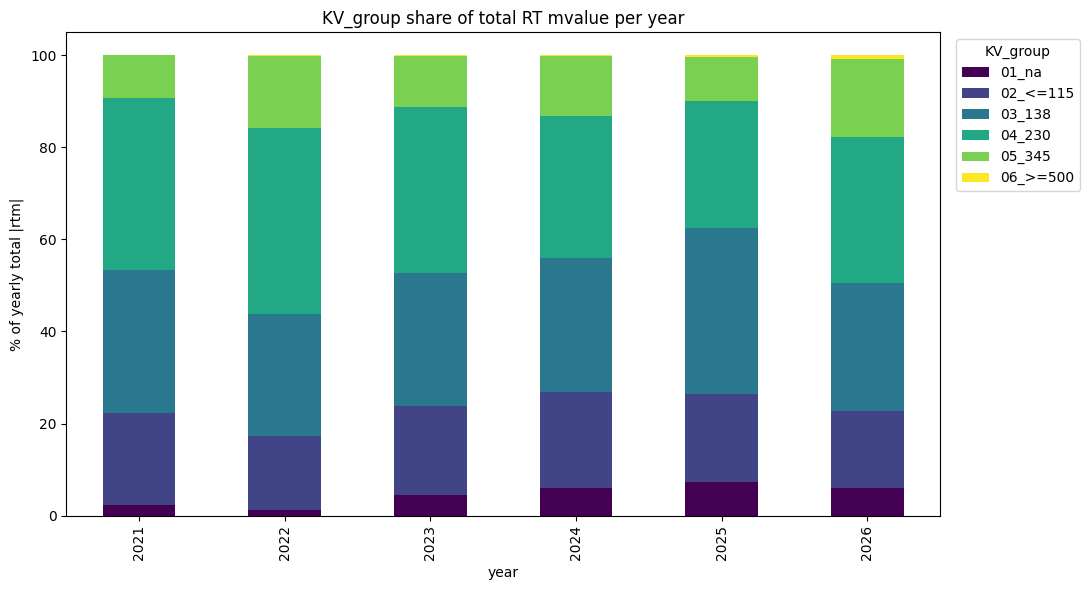

In [76]:
# === KV_group share of yearly mvalue ===
# attach KV_group (from kv_per_con -> table_kv_final, rolled up to family) onto mv5,
# then per year compute each KV_group's % of that year's total |mvalue|.
import matplotlib.pyplot as plt

MVAL = 'rtm'   # 'rtm' = RT mvalue, 'dam' = DA mvalue

kv_fam = table_kv_final[['constraint_family_num', 'KV_group']].drop_duplicates('constraint_family_num')
mvkv = mv5.merge(kv_fam, on='constraint_family_num', how='left')
# sanity: did the family key actually match? (catches dtype mismatch / KV-table subset)
print(f"KV_group match: {mvkv['KV_group'].notna().mean():.1%} of mv5 family-days | "
      f"mv5 families={mv5['constraint_family_num'].nunique()}, "
      f"KV-table families={kv_fam['constraint_family_num'].nunique()} | "
      f"dtypes: mv5={mv5['constraint_family_num'].dtype}, kv={kv_fam['constraint_family_num'].dtype}")
mvkv['KV_group'] = mvkv['KV_group'].fillna('01_na')
mvkv['year'] = pd.to_datetime(mvkv['dt']).dt.year
mvkv['mabs'] = mvkv[MVAL].abs()                    # mvalue is negative when binding -> use magnitude

# sum |mvalue| per (year, KV_group) -> % of that year's total
yr_kv  = mvkv.groupby(['year', 'KV_group'], as_index=False)['mabs'].sum()
yr_kv['pct'] = 100 * yr_kv['mabs'] / yr_kv.groupby('year')['mabs'].transform('sum')

pivot = yr_kv.pivot(index='year', columns='KV_group', values='pct').fillna(0).sort_index()
print(f"% of yearly total |{MVAL}| by KV_group:")
display(pivot.round(1))

ax = pivot.plot(kind='bar', stacked=True, figsize=(11, 6), colormap='viridis')
ax.set_xlabel('year'); ax.set_ylabel(f'% of yearly total |{MVAL}|')
ax.set_title(f"KV_group share of total {'RT' if MVAL=='rtm' else 'DA'} mvalue per year")
ax.legend(title='KV_group', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.show()